## Blood Transfusion Service Center Data Set
Data taken from the Blood Transfusion Service Center in Hsin-Chu City in Taiwan -- this is a classification problem. 

Data Set Characteristics: Multivariate  
Number of Instances: 748  
Area: Business  
Attribute Characteristics: Real  
Number of Attributes: 5  
Date Donated: 2008-10-03  
Associated Tasks: Classification  
Missing Values? N/A  

Source:  [Blood Transfusion Service Center Data](https://www.kaggle.com/datasets/vstacknocopyright/blood-transfusion-service-center-data/data)  

Attribute Information:  
Given is the variable name, variable type, the measurement unit and a brief   
description. The "Blood Transfusion Service Center" is a classification problem.   
The order of this listing corresponds to the order of numerals along the rows of   
the database.

R (Recency - months since last donation),  
F (Frequency - total number of donation),  
M (Monetary - total blood donated in c.c.),  
T (Time - months since first donation),  
and a binary variable representing whether he/she donated blood in March  
(1 stand for donating blood; 0 stands for not donating blood).  


## Project content 

Developed a classifier for predicting the variable "whether they donated blood in March" using:
1. Logistic regression
2. Random forest 
3. KNN

Model quality assessment (metrics and results)

In [1]:
import pandas as pd

In [2]:
#Reading the file, including different type of the separator
df = pd.read_csv('./Data/Blood_1.csv',sep=';')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Recency (months)                     748 non-null    int64  
 1   Frequency (times)                    748 non-null    int64  
 2   Monetary (c.c. blood)                748 non-null    int64  
 3   Time (months)                        748 non-null    int64  
 4   Whether they donated blood in March  748 non-null    int64  
 5   Time/Frequency                       748 non-null    str    
 6   Unnamed: 6                           0 non-null      float64
dtypes: float64(1), int64(5), str(1)
memory usage: 41.0 KB


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),Whether they donated blood in March,Time/Frequency,Unnamed: 6
0,2,50,12500,98,1,"1,96",NaN
1,0,13,3250,28,1,"2,15",NaN
2,1,16,4000,35,1,"2,19",NaN
3,2,20,5000,45,1,"2,25",NaN
4,1,24,6000,77,0,"3,21",NaN


In [3]:
#Column 'Time/Frequency' is a string - should be chnaged to float
df['Time/Frequency'] = df['Time/Frequency'].astype(str).str.replace(',','.').astype(float)
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),Whether they donated blood in March,Time/Frequency,Unnamed: 6
0,2,50,12500,98,1,1.96,NaN
1,0,13,3250,28,1,2.15,NaN
2,1,16,4000,35,1,2.19,NaN
3,2,20,5000,45,1,2.25,NaN
4,1,24,6000,77,0,3.21,NaN


In [4]:
#Deleting last column (it's empty)
df = df.drop(columns=['Unnamed: 6'])
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),Whether they donated blood in March,Time/Frequency
0,2,50,12500,98,1,1.96
1,0,13,3250,28,1,2.15
2,1,16,4000,35,1,2.19
3,2,20,5000,45,1,2.25
4,1,24,6000,77,0,3.21


In [5]:
#why there's no decribe for 'Time/Frequency' ???
df.describe()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),Whether they donated blood in March,Time/Frequency
count,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968,8.710749
std,8.095396,5.839307,1459.826781,24.376714,0.426124,7.362750
min,0.000000,1.000000,250.000000,2.000000,0.000000,1.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000,4.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000,6.500000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000,11.500000
max,74.000000,50.000000,12500.000000,98.000000,1.000000,74.000000


In [6]:
# Creating variable for predicting if sb donated blood in march (target)
y = df['Whether they donated blood in March']

# Creating a table without column 'Whether they donated blood in March'
x = df.drop(columns=['Whether they donated blood in March'])

#Checking if the variables have proper dimensions
print(f"Dimensions x: {x.shape}")
print(f"Dimensions y: {y.shape}")

Dimensions x: (748, 5)
Dimensions y: (748,)


In [7]:
#Perparing training set and test set 
from sklearn.model_selection import train_test_split

# 80-20 division 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#How many rows are in train and test sets
print(f"Traning rows number (x_train): {x_train.shape}")
print(f"Test rows number (x_test): {x_test.shape}")

Traning rows number (x_train): (598, 5)
Test rows number (x_test): (150, 5)


In [8]:
#Scaling values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [10]:
#Libraries for logistic regression, random forrest and KNN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Model initialization
class_lr = LogisticRegression(random_state=42)
class_rf = RandomForestClassifier(random_state=42)
class_knn = KNeighborsClassifier()

#Matching x(vairables) to y(outcome)
class_lr.fit(x_train_scaled, y_train)
class_rf.fit(x_train_scaled, y_train)
class_knn.fit(x_train_scaled, y_train)

print("Training done")

Training done


In [13]:
#Testing trained models
from sklearn.metrics import accuracy_score

#Predictions for test data
pred_lr = class_lr.predict(x_test_scaled)
pred_rf = class_rf.predict(x_test_scaled)
pred_knn = class_knn.predict(x_test_scaled)

#Accuracy calculations
acc_lr = accuracy_score(y_test, pred_lr)
acc_rf = accuracy_score(y_test, pred_rf)
acc_knn = accuracy_score(y_test, pred_knn)

#Display of outcome
print(f"Logistic Regression Accuracy: {acc_lr:0.2%}")
print(f"Random Forrest Accuracy: {acc_rf:0.2%}")
print(f"KNeighbours Accuracy: {acc_knn:0.2%}")

Logistic Regression Accuracy: 76.00%
Random Forrest Accuracy: 76.00%
KNeighbours Accuracy: 76.67%


In [16]:
#Creating a table with test and predicted values
comparison_df = pd.DataFrame({
    'Whether they donated blood in March (real values)': y_test.values,
    'Whether they donated blood in March (predicted values)': pred_knn
})

comparison_df.head(20)

,Whether they donated blood in March (real values),Whether they donated blood in March (predicted values)
0,0,0
1,0,0
2,0,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


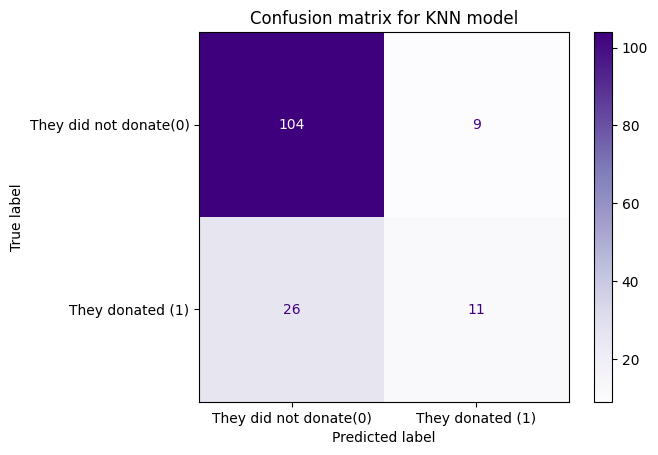

In [ ]:
#For KNN model 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Generating confusion matrix 
cm = confusion_matrix(y_test, pred_knn)

#Generating visualisation
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['They did not donate(0)', 'They donated (1)'])

#Graph 
disp.plot(cmap='Purples')
plt.title('Confusion matrix for KNN model')
plt.show()